# Distribuzione delle lingue

Analisi delle lingue presenti nel dataset:

## Grafico
Il grafico a barre mostra la distribuzione delle varie lingue nel dataset

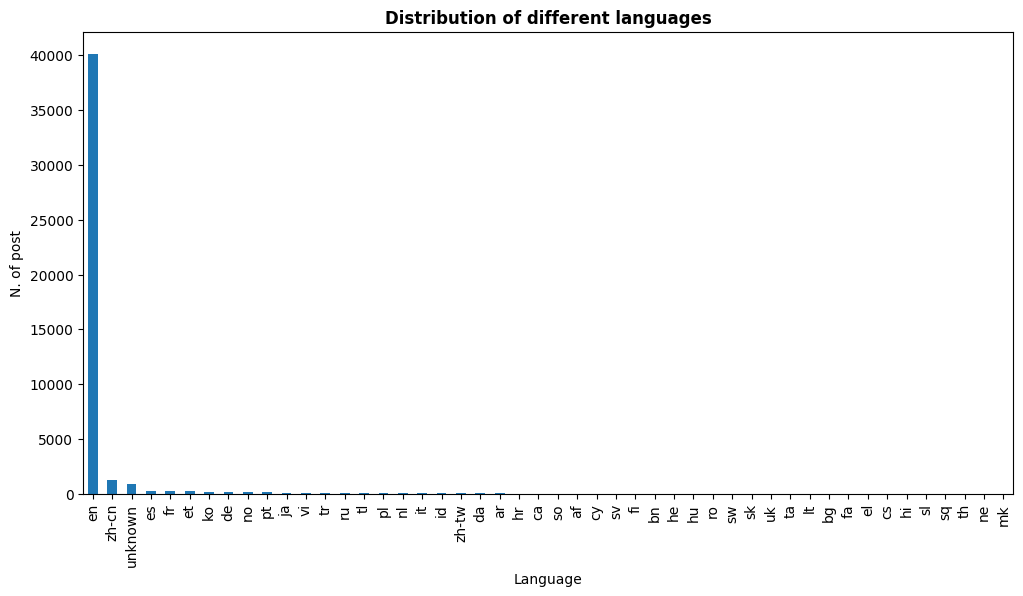

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

data_new = pd.read_parquet('../data/processed/processed_lang.parquet')

data_new['language'].value_counts().plot(kind='bar', figsize=(12,6))
plt.title('Distribution of different languages', fontweight='bold')
plt.ylabel('N. of post')
plt.xlabel('Language')
plt.show()

## Tabella delle prime 10 lingue per frequenza

In [2]:
lang_stats = pd.DataFrame({
    'Counts': data_new['language'].value_counts(),
    'Percentage': (data_new['language'].value_counts() / len(data_new) * 100).round(2)
})

lang_stats = lang_stats.reset_index()
lang_stats.columns = ['Language', 'Counts', 'Percentage']

lang_stats.head(10)

,Language,Counts,Percentage
0,en,40150,90.48
1,zh-cn,1259,2.84
2,unknown,858,1.93
3,es,264,0.59
4,fr,214,0.48
5,et,205,0.46
6,ko,202,0.46
7,de,136,0.31
8,no,114,0.26
9,pt,112,0.25


## Pulizia del dataset

Rimuovo le righe che non sono classificate come inglese

In [16]:
eng_data = data_new[data_new['language'] == 'en']

eng_data.to_parquet('../data/processed/english_data.parquet')